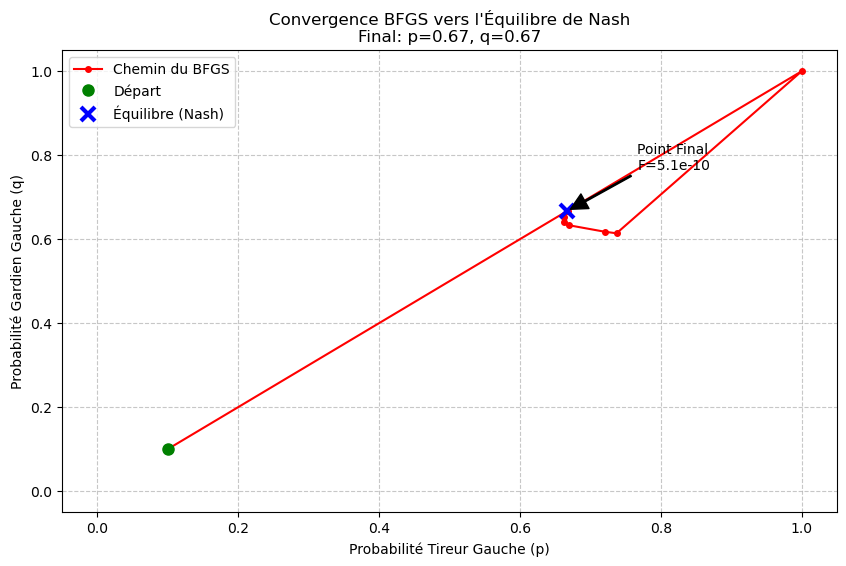

Convergence réussie en 12 itérations.
Résultat : p=0.6667, q=0.6666


In [1]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

def generate_g_functions(A11, A12, A21, A22):
    def get_up(p, q):
        return (p*q*A11 + p*(1-q)*A12 + (1-p)*q*A21 + (1-p)*(1-q)*A22)

    def g_PG(p, q):
        return (q*A11 + (1-q)*A12) - get_up(p, q)

    def g_PD(p, q):
        return (q*A21 + (1-q)*A22) - get_up(p, q)

    def g_KG(p, q):
        return -(p*A11 + (1-p)*A21) - (-get_up(p, q))

    def g_KD(p, q):
        return -(p*A12 + (1-p)*A22) - (-get_up(p, q))

    return g_PG, g_PD, g_KG, g_KD

# --- Configuration du jeu ---
# Tireur fort à gauche (A11=0.5 au lieu de 0)
g_PG, g_PD, g_KG, g_KD = generate_g_functions(0.5, 1, 1, 0)

def F_vec(x):
    p, q = x
    regrets = [g_PG(p, q), g_PD(p, q), g_KG(p, q), g_KD(p, q)]
    return sum(max(r, 0)**2 for r in regrets)

# --- Suivi de l'optimisation ---
historique = []
def callback_bfgs(xk):
    # On enregistre p et q à chaque étape
    historique.append(np.copy(xk))

# --- Lancement du BFGS ---
x0 = np.array([0.1, 0.1]) # Départ un peu excentré pour mieux voir la trajectoire
bounds = [(0, 1), (0, 1)]
historique.append(np.copy(x0)) # Ajout du point de départ

res = minimize(F_vec, x0, method='L-BFGS-B', bounds=bounds, callback=callback_bfgs)

# --- Affichage et Graphique ---
if res.success:
    p_opt, q_opt = res.x
    pts = np.array(historique)
    
    plt.figure(figsize=(10, 6))
    
    # 1. Dessiner le chemin parcouru
    plt.plot(pts[:, 0], pts[:, 1], 'ro-', label="Chemin du BFGS", markersize=4)
    plt.plot(pts[0, 0], pts[0, 1], 'go', label="Départ", markersize=8)
    plt.plot(p_opt, q_opt, 'bx', label="Équilibre (Nash)", markersize=10, markeredgewidth=3)

    # 2. Mise en forme
    plt.xlim(-0.05, 1.05)
    plt.ylim(-0.05, 1.05)
    plt.xlabel('Probabilité Tireur Gauche (p)')
    plt.ylabel('Probabilité Gardien Gauche (q)')
    plt.title(f'Convergence BFGS vers l\'Équilibre de Nash\nFinal: p={p_opt:.2f}, q={q_opt:.2f}')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    # Annotation pour donner du sens
    plt.annotate(f'Point Final\nF={res.fun:.1e}', xy=(p_opt, q_opt), xytext=(p_opt+0.1, q_opt+0.1),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1))

    plt.show()

    print(f"Convergence réussie en {len(pts)} itérations.")
    print(f"Résultat : p={p_opt:.4f}, q={q_opt:.4f}")

In [16]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [22]:
def generate_cooperative_regrets():
    def u(p, q):
        return p*q + (1-p)*(1-q)

    # Ici, les DEUX joueurs veulent maximiser u.
    # Le regret est la différence entre le max possible (1) et le gain actuel.
    def regret_P1(p, q): return 1 - u(p, q)
    def regret_P2(p, q): return 1 - u(p, q)

    return regret_P1, regret_P2

regret_P1, regret_P2 = generate_cooperative_regrets()

def F_vec(x):
    p, q = x
    # On minimise la somme des regrets au carré pour que les deux atteignent le max
    return regret_P1(p, q)**2 + regret_P2(p, q)**2

In [17]:


def generate_g_functions_v2():
    # Nouvelle fonction d'utilité : u(p,q) = pq + (1-p)(1-q)
    def get_up(p, q):
        return p*q + (1-p)*(1-q)

    # Regrets pour le Joueur 1 (veut maximiser u)
    # g_P1(p,q) = (Gain si joue pur) - (Gain actuel)
    def g_P1_A(p, q): return get_up(1, q) - get_up(p, q) # Regret de ne pas avoir joué p=1
    def g_P1_B(p, q): return get_up(0, q) - get_up(p, q) # Regret de ne pas avoir joué p=0

    # Si les objectifs sont opposés
    # Regrets pour le Joueur 2 (veut minimiser u, donc maximiser -u)
    # g_P2(p,q) = (Perte si joue pur) - (Perte actuelle)
    #def g_P2_A(p, q): return (-get_up(p, 1)) - (-get_up(p, q)) 
    #def g_P2_B(p, q): return (-get_up(p, 0)) - (-get_up(p, q))


     # Si les objectifs sont les memes : 
    def g_P2_A(p, q): return (get_up(p, 1)) - (get_up(p, q)) 
    def g_P2_B(p, q): return (get_up(p, 0)) - (get_up(p, q))
    return g_P1_A, g_P1_B, g_P2_A, g_P2_B

# --- Configuration du jeu ---
g_P1A, g_P1B, g_P2A, g_P2B = generate_g_functions_v2()

def F_vec(x):
    p, q = x
    # On calcule les regrets. Si le regret est négatif, c'est qu'on est déjà meilleur.
    regrets = [g_P1A(p, q), g_P1B(p, q), g_P2A(p, q), g_P2B(p, q)]
    # La fonction vaut 0 si et seulement si tous les regrets sont <= 0 (Équilibre de Nash)
    return sum(max(r, 0)**2 for r in regrets)

In [57]:
def affichage(res,historique):
    # --- Affichage et Graphique ---
    if res.success:
        p_opt, q_opt = res.x
        pts = np.array(historique)
        
        plt.figure(figsize=(10, 6))
        
        # 1. Dessiner le chemin parcouru
        plt.plot(pts[:, 0], pts[:, 1], 'ro-', label="Chemin du BFGS", markersize=4)
        plt.plot(pts[0, 0], pts[0, 1], 'go', label="Départ", markersize=8)
        plt.plot(p_opt, q_opt, 'bx', label="Équilibre (Nash)", markersize=10, markeredgewidth=3)

        # 2. Mise en forme
        plt.xlim(-0.05, 1.05)
        plt.ylim(-0.05, 1.05)
        plt.xlabel('Probabilité Tireur Gauche (p)')
        plt.ylabel('Probabilité Gardien Gauche (q)')
        plt.title(f'Convergence BFGS vers l\'Équilibre de Nash\nFinal: p={p_opt:.2f}, q={q_opt:.2f}')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend()
        
        # Annotation pour donner du sens
        plt.annotate(f'Point Final\nF={res.fun:.1e}', xy=(p_opt, q_opt), xytext=(p_opt+0.1, q_opt+0.1),
                    arrowprops=dict(facecolor='black', shrink=0.05, width=1))

        plt.show()

        print(f"Convergence réussie en {len(pts)} itérations.")
        print(f"Résultat : p={p_opt:.4f}, q={q_opt:.4f}")

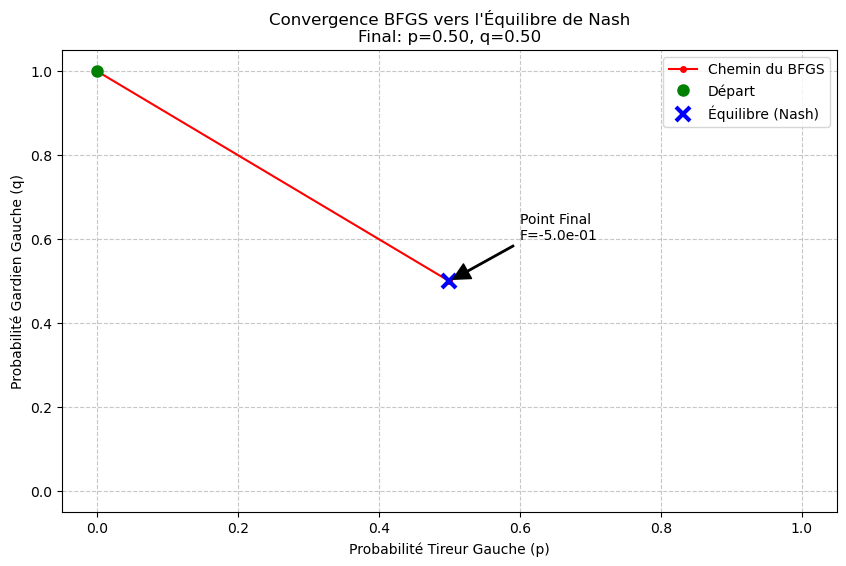

Convergence réussie en 3 itérations.
Résultat : p=0.5000, q=0.5000


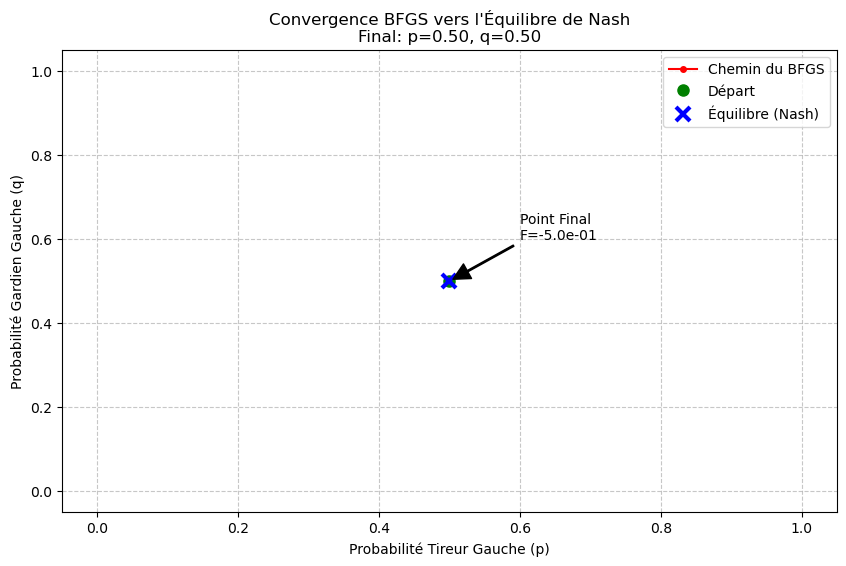

Convergence réussie en 1 itérations.
Résultat : p=0.5000, q=0.5000


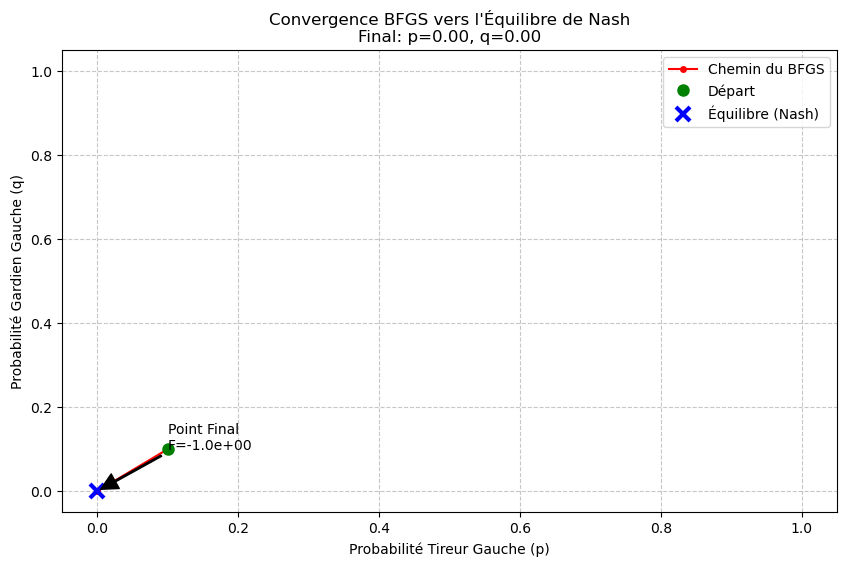

Convergence réussie en 2 itérations.
Résultat : p=0.0000, q=0.0000


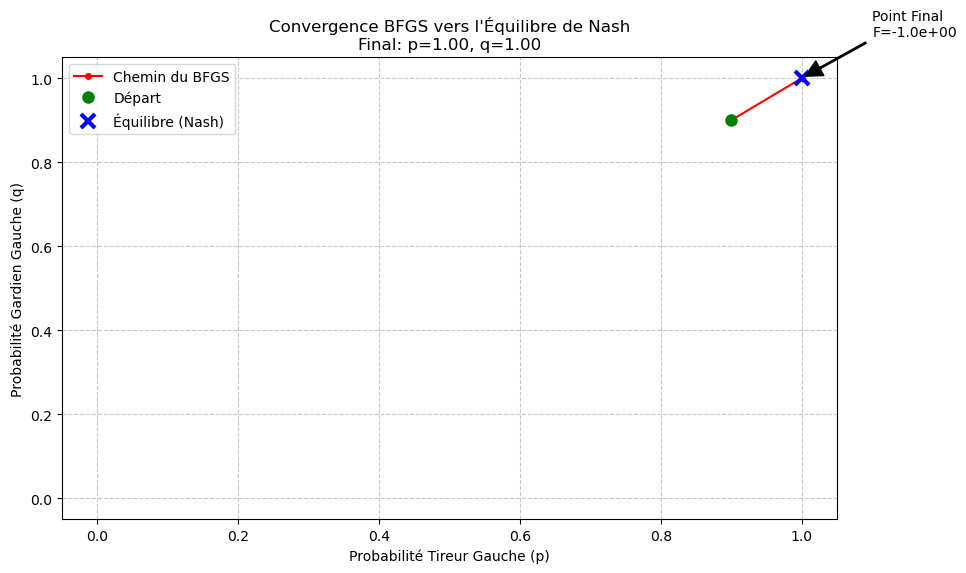

Convergence réussie en 2 itérations.
Résultat : p=1.0000, q=1.0000


In [60]:
# --- Suivi de l'optimisation ---
historique = []
def callback_bfgs(xk):
    # On enregistre p et q à chaque étape
    historique.append(np.copy(xk))

# --- Lancement du BFGS ---
x0 = np.array([00, 1]) # Départ un peu excentré pour mieux voir la trajectoire
bounds = [(0, 1), (0, 1)]
historique.append(np.copy(x0)) # Ajout du point de départ

res = minimize(F_vec, x0, method='L-BFGS-B', bounds=bounds, callback=callback_bfgs)

affichage(res,historique)
# --- Lancement du BFGS ---
# --- Suivi de l'optimisation ---
historique = []
x0 = np.array([1/2, 1/2]) # Départ un peu excentré pour mieux voir la trajectoire
bounds = [(0, 1), (0, 1)]
historique.append(np.copy(x0)) # Ajout du point de départ

res = minimize(F_vec, x0, method='L-BFGS-B', bounds=bounds, callback=callback_bfgs)

affichage(res,historique)
# --- Lancement du BFGS ---
# --- Suivi de l'optimisation ---
historique = []
x0 = np.array([0.1, 0.1]) # Départ un peu excentré pour mieux voir la trajectoire
bounds = [(0, 1), (0, 1)]
historique.append(np.copy(x0)) # Ajout du point de départ

res = minimize(F_vec, x0, method='L-BFGS-B', bounds=bounds, callback=callback_bfgs)

affichage(res,historique)

historique = []
x0 = np.array([0.9, 0.9]) # Départ un peu excentré pour mieux voir la trajectoire
bounds = [(0, 1), (0, 1)]
historique.append(np.copy(x0)) # Ajout du point de départ

res = minimize(F_vec, x0, method='L-BFGS-B', bounds=bounds, callback=callback_bfgs)

affichage(res,historique)

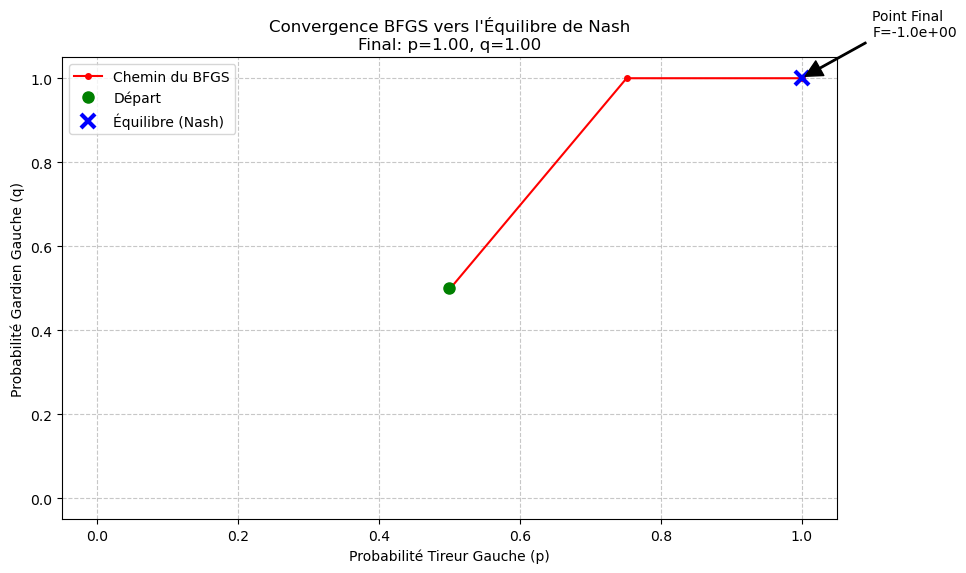

Convergence réussie en 4 itérations.
Résultat : p=1.0000, q=1.0000


In [56]:
# --- Suivi de l'optimisation ---

def F_vec(x):
    p, q = x
    def u(p, q):
        return p*q + (1-p)*(1-q)
    return -u(p,q)
historique = []
def callback_bfgs(xk):
    # On enregistre p et q à chaque étape
    historique.append(np.copy(xk))

# --- Lancement du BFGS ---
x0 = np.array([1/2, 1/2 +.001]) # Départ un peu excentré pour mieux voir la trajectoire
bounds = [(0, 1), (0, 1)]
historique.append(np.copy(x0)) # Ajout du point de départ

res = minimize(F_vec, x0, method='L-BFGS-B', bounds=bounds, callback=callback_bfgs)

# --- Affichage et Graphique ---
if res.success:
    p_opt, q_opt = res.x
    pts = np.array(historique)
    
    plt.figure(figsize=(10, 6))
    
    # 1. Dessiner le chemin parcouru
    plt.plot(pts[:, 0], pts[:, 1], 'ro-', label="Chemin du BFGS", markersize=4)
    plt.plot(pts[0, 0], pts[0, 1], 'go', label="Départ", markersize=8)
    plt.plot(p_opt, q_opt, 'bx', label="Équilibre (Nash)", markersize=10, markeredgewidth=3)

    # 2. Mise en forme
    plt.xlim(-0.05, 1.05)
    plt.ylim(-0.05, 1.05)
    plt.xlabel('Probabilité Tireur Gauche (p)')
    plt.ylabel('Probabilité Gardien Gauche (q)')
    plt.title(f'Convergence BFGS vers l\'Équilibre de Nash\nFinal: p={p_opt:.2f}, q={q_opt:.2f}')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    # Annotation pour donner du sens
    plt.annotate(f'Point Final\nF={res.fun:.1e}', xy=(p_opt, q_opt), xytext=(p_opt+0.1, q_opt+0.1),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1))

    plt.show()

    print(f"Convergence réussie en {len(pts)} itérations.")
    print(f"Résultat : p={p_opt:.4f}, q={q_opt:.4f}")

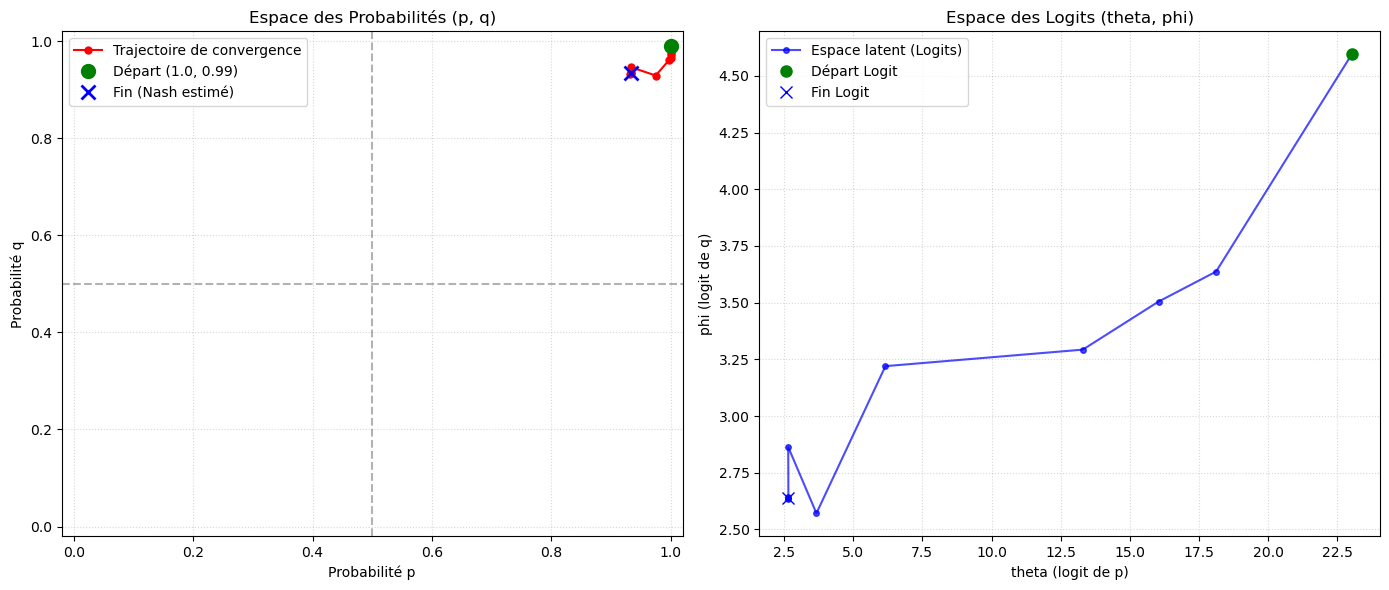

------------------------------
POINT DE DÉPART : p=1.0, q=0.99
RÉSULTATS FINAUX :
  Logits : theta=2.6386, phi=2.6386
  Probas : p=0.9333, q=0.9333
  Perte finale : 2.06e-02
------------------------------


In [54]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# --- Fonctions de base ---
def sigmoid(x):
    """Transforme un logit en probabilité [0, 1]"""
    return 1 / (1 + np.exp(-x))

def inverse_sigmoid(p):
    """Transforme une probabilité en logit [-inf, +inf] (Fonction Logit)"""
    # On clip légèrement pour éviter ln(0) ou ln(inf)
    p = np.clip(p, 1e-10, 1 - 1e-10)
    return np.log(p / (1 - p))

def generate_softmax_regret_logic(lam=0.01):
    def u(p, q):
        # Fonction d'utilité du jeu
        return p*q + (1-p)*(1-q)

    def F_vec_softmax(params):
        theta, phi = params
        # Passage aux probabilités
        p = sigmoid(theta)
        q = sigmoid(phi)

        # Calcul des regrets (Joueur 1 maximise u, Joueur 2 minimise u)
        # Regret = (Gain potentiel max) - (Gain actuel)
        regret_P1 = max(0, u(1, q) - u(p, q))**2 + max(0, u(0, q) - u(p, q))**2
        regret_P2 = max(0, (u(p, 1)) - (u(p, q)))**2 + max(0, (u(p, 0)) - (u(p, q)))**2
        
        # Somme des regrets + Régularisation L2 (évite les logits infinis)
        total_loss = (regret_P1 + regret_P2) + lam * (theta**2 + phi**2)
        return total_loss

    return F_vec_softmax

# --- 1. Configuration et Point de départ ---
lam = 0.001  # Force de la régularisation
p0_souhaite = 1.0  # Probabilité initiale Joueur 1
q0_souhaite = 0.99  # Probabilité initiale Joueur 2

# Transformation en logits pour l'optimiseur
theta0 = inverse_sigmoid(p0_souhaite)
phi0 = inverse_sigmoid(q0_souhaite)
theta_phi_0 = np.array([theta0, phi0])

# --- 2. Préparation de l'historique ---
# On commence l'historique avec le point exact de départ
historique_logits = [np.copy(theta_phi_0)]

def callback(xk):
    # Cette fonction est appelée par scipy à chaque itération réussie
    historique_logits.append(np.copy(xk))

# --- 3. Lancement de l'Optimisation ---
f_to_minimize = generate_softmax_regret_logic(lam)
res = minimize(f_to_minimize, theta_phi_0, method='L-BFGS-B', callback=callback)

# --- 4. Préparation des données pour les graphiques ---
logits_pts = np.array(historique_logits)
p_pts = sigmoid(logits_pts[:, 0])
q_pts = sigmoid(logits_pts[:, 1])

# --- 5. Visualisation ---
plt.figure(figsize=(14, 6))

# Subplot 1 : Espace des Probabilités
plt.subplot(1, 2, 1)
plt.plot(p_pts, q_pts, 'ro-', markersize=5, linewidth=1.5, label='Trajectoire de convergence')
plt.plot(p_pts[0], q_pts[0], 'go', label=f'Départ ({p0_souhaite}, {q0_souhaite})', markersize=10)
plt.plot(p_pts[-1], q_pts[-1], 'bx', label='Fin (Nash estimé)', markersize=10, markeredgewidth=2)

# Forcer l'affichage sur tout l'espace 0-1
plt.xlim(-0.02, 1.02)
plt.ylim(-0.02, 1.02)

plt.axhline(0.5, color='k', linestyle='--', alpha=0.3)
plt.axvline(0.5, color='k', linestyle='--', alpha=0.3)
plt.title("Espace des Probabilités (p, q)")
plt.xlabel("Probabilité p")
plt.ylabel("Probabilité q")
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.legend()

# Subplot 2 : Espace des Logits
plt.subplot(1, 2, 2)
plt.plot(logits_pts[:, 0], logits_pts[:, 1], 'bo-', markersize=4, alpha=0.7, label='Espace latent (Logits)')
plt.plot(logits_pts[0, 0], logits_pts[0, 1], 'go', label='Départ Logit', markersize=8)
plt.plot(logits_pts[-1, 0], logits_pts[-1, 1], 'bx', label='Fin Logit', markersize=8)

plt.title("Espace des Logits (theta, phi)")
plt.xlabel("theta (logit de p)")
plt.ylabel("phi (logit de q)")
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

# --- Résultats chiffrés ---
p_final = sigmoid(res.x[0])
q_final = sigmoid(res.x[1])
print("-" * 30)
print(f"POINT DE DÉPART : p={p0_souhaite}, q={q0_souhaite}")
print(f"RÉSULTATS FINAUX :")
print(f"  Logits : theta={res.x[0]:.4f}, phi={res.x[1]:.4f}")
print(f"  Probas : p={p_final:.4f}, q={q_final:.4f}")
print(f"  Perte finale : {res.fun:.2e}")
print("-" * 30)